<a href="https://colab.research.google.com/github/MaximilienRoten/2025_Intro_Python/blob/main/feedback_old_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feedback : Introduction to scientific computing with Python**

In this file we will discuss an error i got while running my code for the **8th question** of the exercice about hurricanes (W3_S2). I will explain my thought process and the steps i took to solve it.

First we need to **load the data** needed for this exercise and install relevant librairies. The following code was given to us by the teaching staff.

In [ ]:
#Install GeoPandas' dependencies
!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 12.1 MB/s eta 0:00:00


In [ ]:
#Install GeoPandas
!pip install --upgrade geopandas

In [ ]:
import pooch
# Download the data used in this notebook
data = pooch.retrieve('https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew?download=1',
                          known_hash='200a740d0e448aa9e4e03d8a9965a70f228442a2da28d804c8e2337d0ef9749e',
                          processor=pooch.Unzip()
                          )

Unzipping contents of '/root/.cache/pooch/3d43e48bb7d0d0370db00be3096108fe-EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew' to '/root/.cache/pooch/3d43e48bb7d0d0370db00be3096108fe-EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew.unzip'


In [ ]:
# And ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Import GeoPandas (as gpd), pandas, and matplotlib
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

##Preparing the data
The next steps allow us to read the data with geopandas and to allocate it to a dataset called country. It contains all the informations we need to map the US.

In [ ]:
# Find the index of the country file
countryindex = next(i for i, f in enumerate(data) if 'gz_2010_us_040_00_5m.json' in f)
# Find the index of the Florence cyclone
florenceindex = next(i for i, f in enumerate(data) if 'florence.csv' in f)

In [ ]:
# Read data with the geopandas function
path = data[countryindex]
# Use geopandas to read the file and call it country
country = gpd.read_file(path)

We can do the same to put the hurricane data in a dataframe.

In [ ]:
# Read in the hurricane florence data, change the longitude, and have a look at the hurricane florence dataframe
tc_path = data[florenceindex]
florence = pd.read_csv(tc_path)
florence = florence.drop(['AdvisoryNumber', 'Forecaster', 'Received'], axis=1)
florence['Long'] = 0 - florence['Long']

In [ ]:
# Create a geodataframe from the hurricane florence dataframe
gdf_florence = gpd.GeoDataFrame(florence, geometry=gpd.points_from_xy(florence.Long, florence.Lat))

# **Plotting and error**
After doing all of this we are ready to take on the last exercise which consists in plotting the USA, annotating the states and plotting the hurricane path inside the US. This is the code that was given to us and that i tried to fill :

    df = country[country[--].isin([--,--]) == False]

    ax = df.plot(figsize=(30,20))

     _ = df.apply(lambda x: ax.____(s=x['NAME'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)

    res_intersection = gdf_florence.____(country, how='intersection')

    ____.plot(ax=ax, color='red', marker="*", markersize=25)

Then i tried to complete the blanks and ran the code. Which gave me an error for line 5 :

    TypeError: Axes.annotate() missing 1 required positional argument: 'text'


TypeError: Axes.annotate() missing 1 required positional argument: 'text'

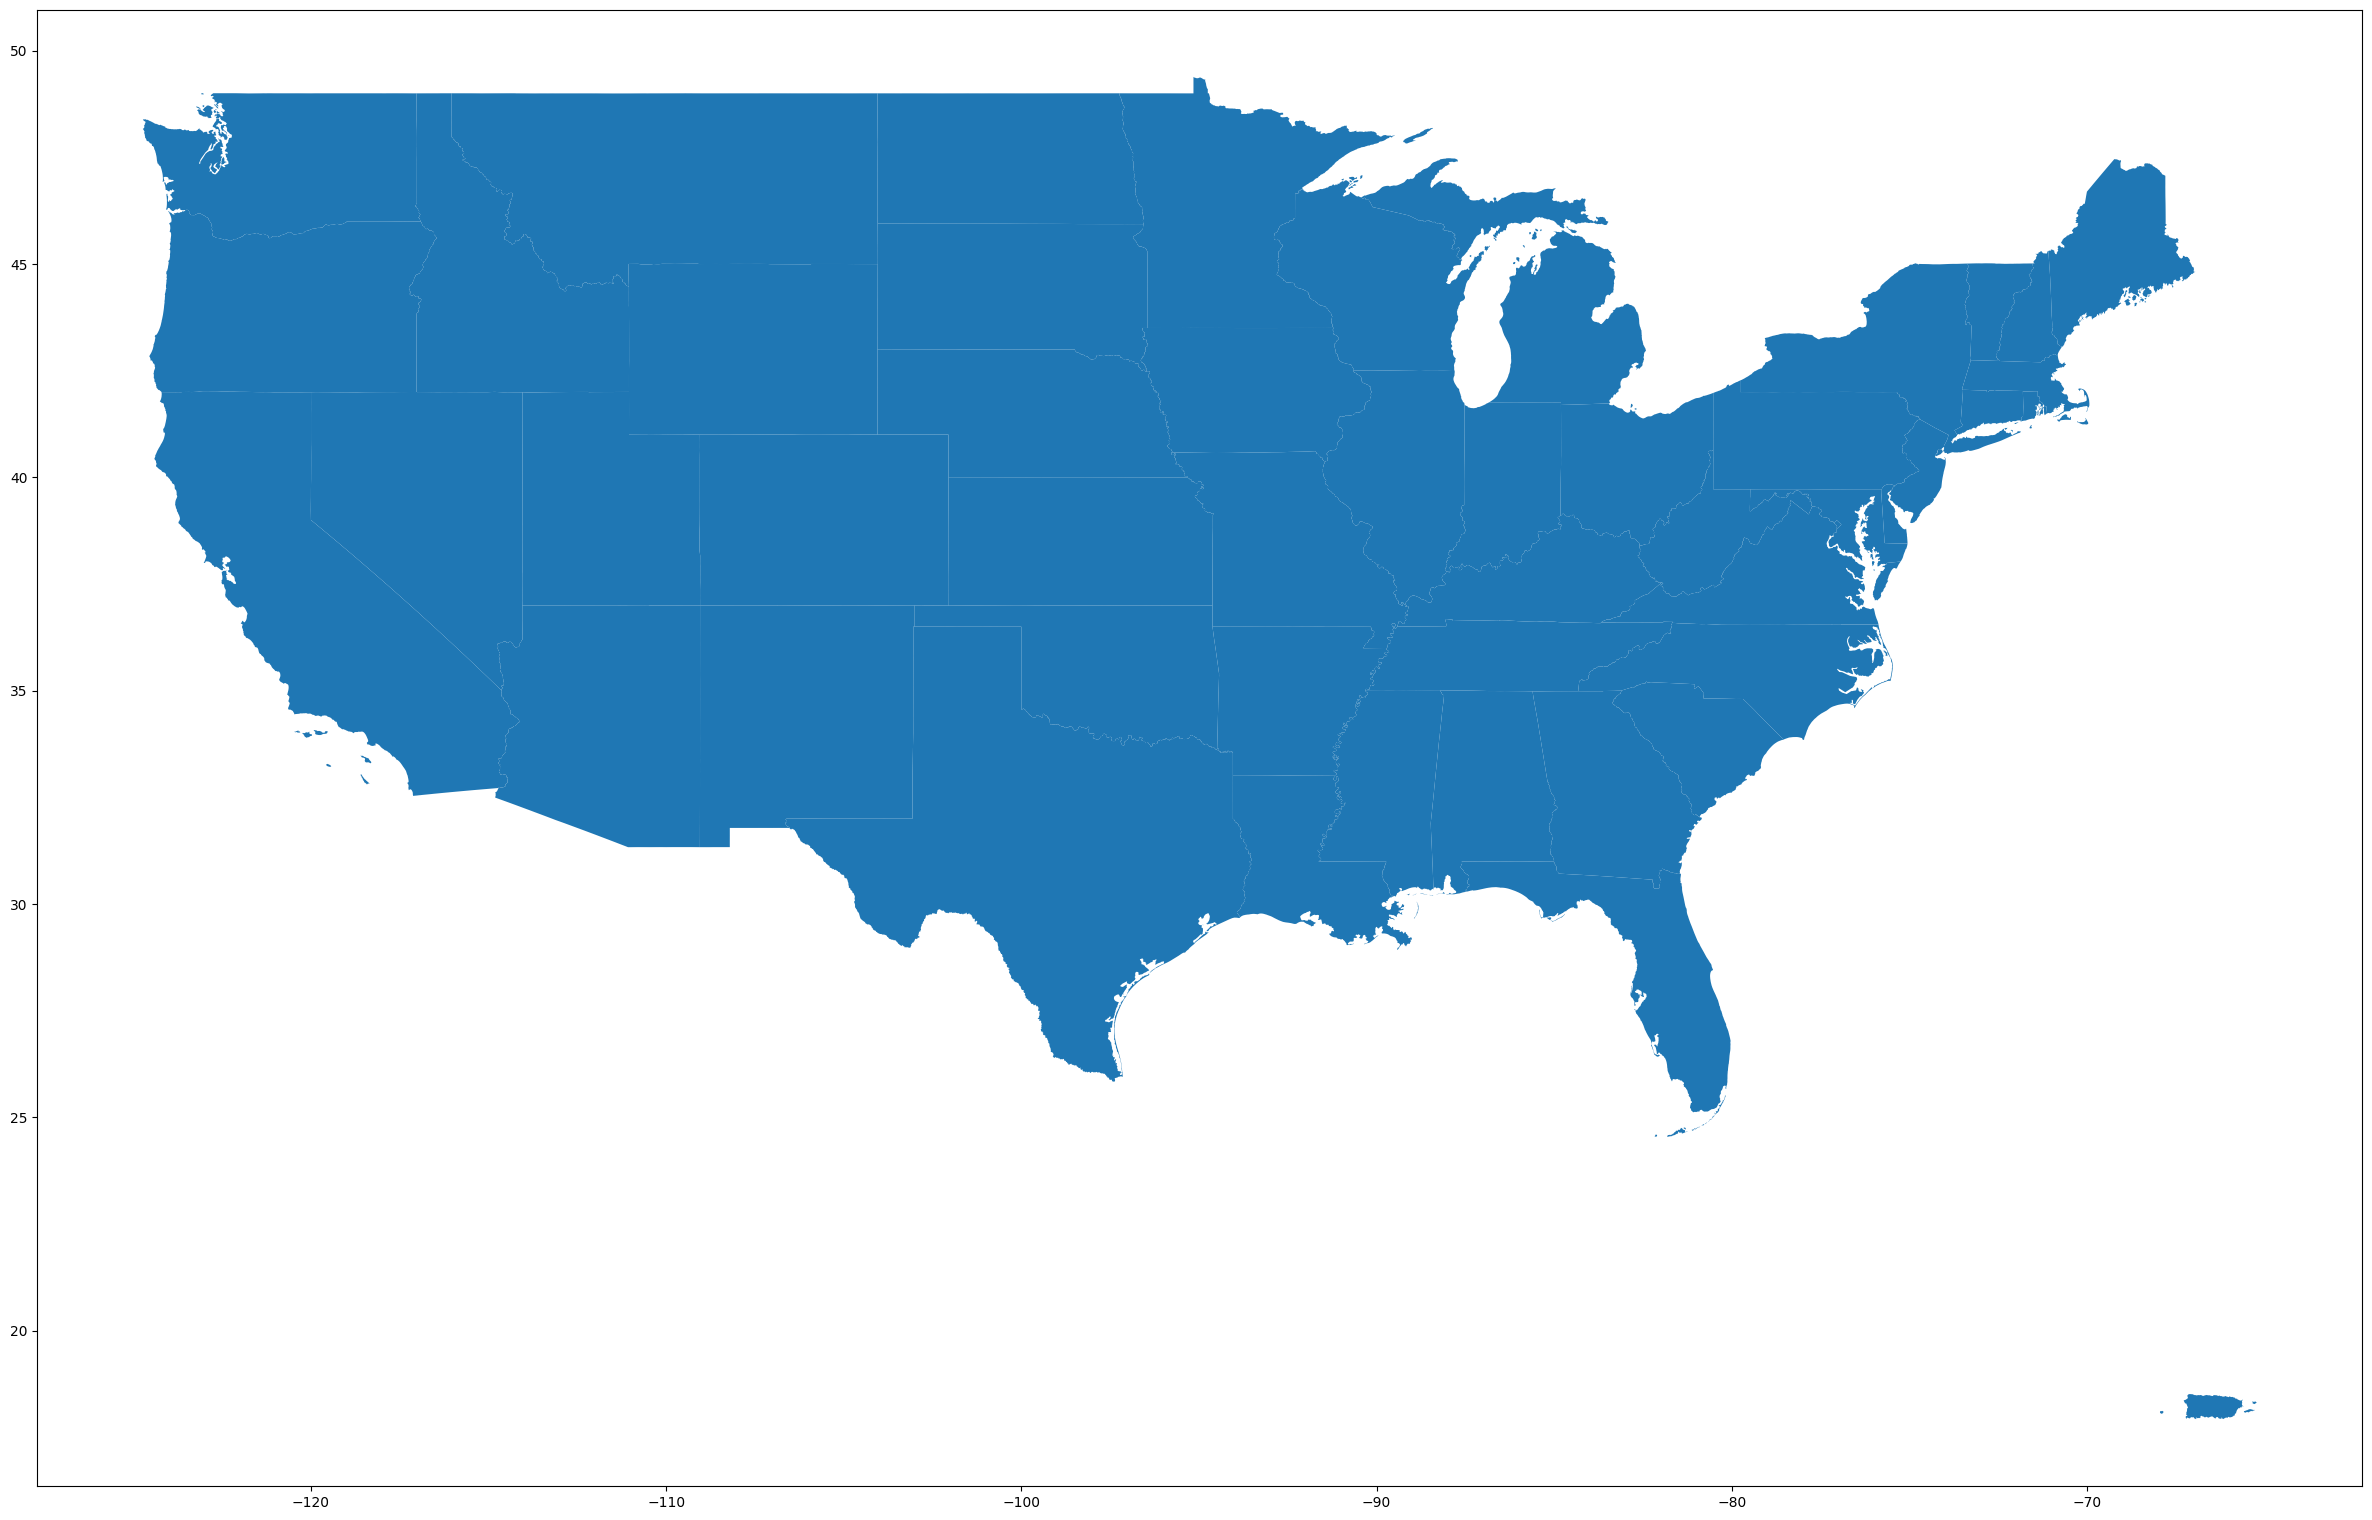

In [ ]:
# Plot the US states without Alaska and Hawaii
df = country[country['NAME'].isin(['Alaska','Hawaii']) == False]
ax = df.plot(figsize=(30,20))
#  Annotate the US states with their names
_ = df.apply(lambda x: ax.annotate(s=x['NAME'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)
# Select the hurricane trajectory points inside the US boundary with the overlay operation
res_intersection = gdf_florence.overlay(country, how='intersection')
# Plot the hurricane trajectory inside US boundary
res_intersection.plot(ax=ax, color='red', marker="*", markersize=25)

To solve this problem i searched the documentation for the function [Axes.annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html) wich the error points as the problem. The function is defined like this :

    Axes.annotate(text, xy, xytext=None, xycoords='data', textcoords=None, arrowprops=None, annotation_clip=None, **kwargs)

I identified that the problem was coming from the text argument wich didn't appear in the code that was suggested, having **s=['NAME']** in its place.
I then replaced it with **text=x['NAME']** and ran the code again, having it working as intended this time.



<Axes: >

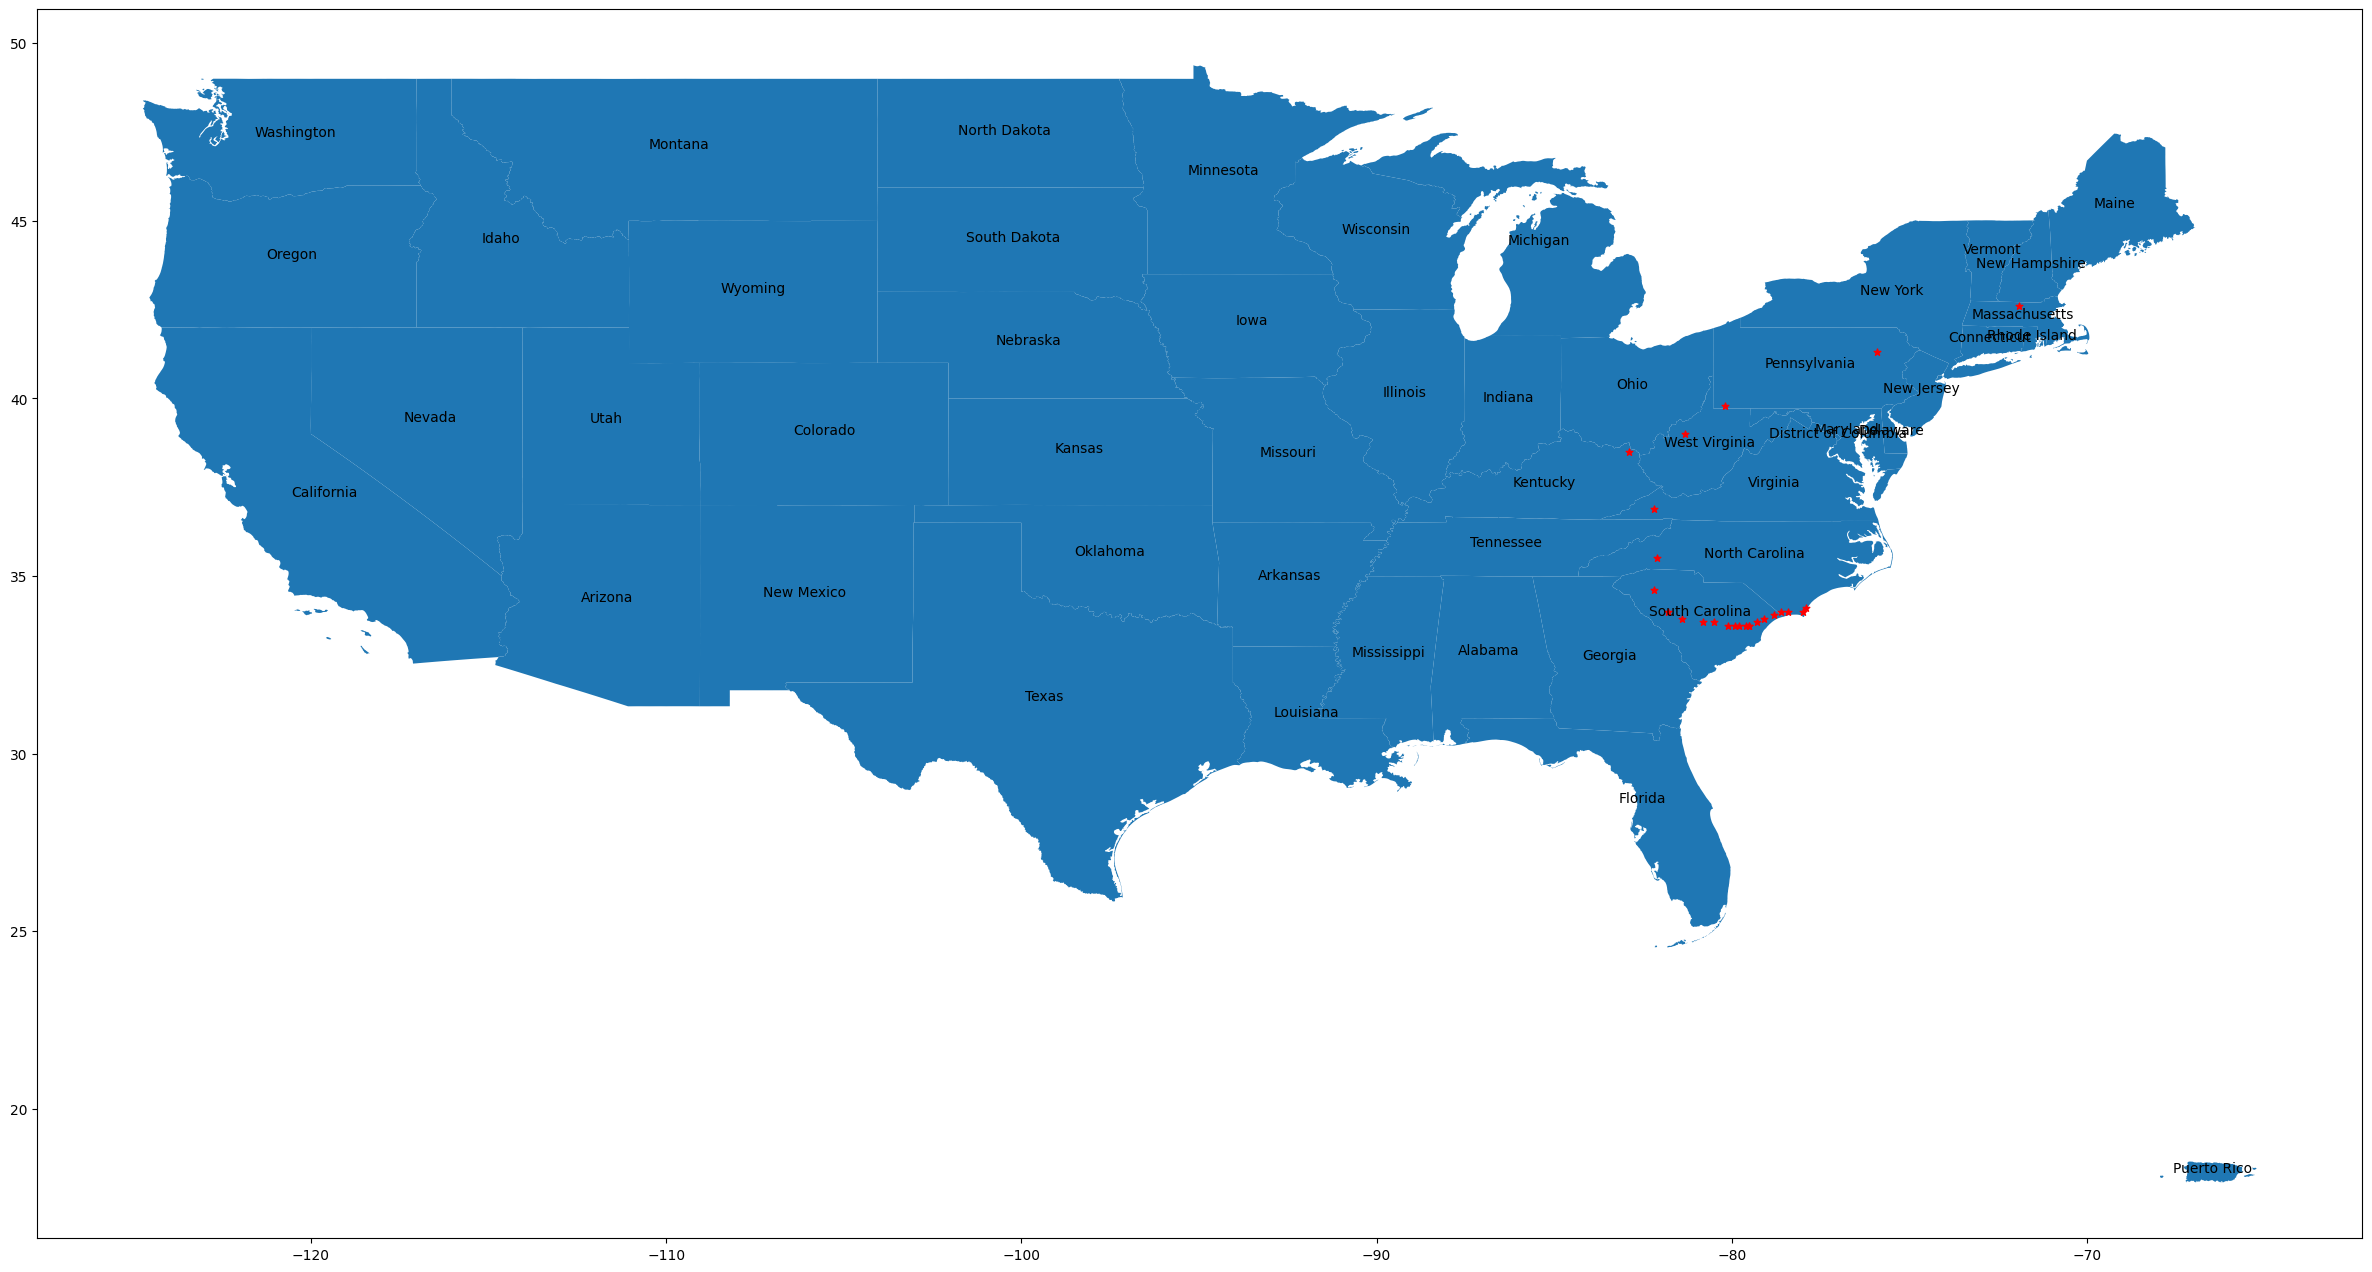

In [ ]:
# Plot the US states without Alaska and Hawaii
df = country[country['NAME'].isin(['Alaska','Hawaii']) == False]
ax = df.plot(figsize=(30,20))
#  Annotate the US states with their names
_ = df.apply(lambda x: ax.annotate(text=x['NAME'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)
# Select the hurricane trajectory points inside the US boundary with the overlay operation
res_intersection = gdf_florence.overlay(country, how='intersection')
# Plot the hurricane trajectory inside US boundary
res_intersection.plot(ax=ax, color='red', marker="*", markersize=25)

# **Closing Remark**
Great the code works, but why was the suggestion wrong ? Did the teaching staff make a mistake ? During my google search, I found that the function Axes.annotate had actually 2 relevant links, the second one being an old and outdated version of the [function](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.annotate.html). There i found out that **s** was an old way to indicate the **text** parameter.

    text : str
      The text of the annotation. s is a deprecated synonym for this parameter.

Matplotlib is an ever-changing library and a lot of functions or syntaxes can change in a small amount of time. It is important to always check if you are consulting the correct documentation.